1. 25Hz 워치 데이터(A)에서 ACC(x,y,z)**를 읽습니다.

2. START_DT를 기준으로 샘플 인덱스에 따라 절대시간(dt)을 만들고, T0~T1 구간만 자릅니다.

3. acc_mag = sqrt(ax^2+ay^2+az^2)로 움직임 크기를 만듭니다.

4. 20초 윈도우(50% overlap)로 나눠서, 각 윈도우마다 std(움직임 변동) + range(충격/스파이크 성향)를 계산합니다.

5. std와 range가 상위 5%(Q=0.95) 이상인 윈도우를 artifact(움직임 큰 구간)로 표시합니다. (OR라서 둘 중 하나만 커도 artifact)

6. artifact가 아닌 윈도우들을 이어 붙여서 정적인 구간(keep_ranges)을 만들고, 너무 짧은 구간은 버립니다(기본 60초 미만 제거)

<저장되는 산출물(파일)>

OUT_DIR 아래로 다음이 저장됩니다.

- acc_window_stats.csv : 전체 윈도우 통계 + 임계 + keep/artifact 라벨
- keep_windows.csv : keep 윈도우만
- keep_ranges.csv : 병합된 keep 연속 구간(핵심 결과)
- artifact_windows.csv : 아티팩트 윈도우만
- acc_analysis.png : 6개 플롯(원신호+keep음영, mean/std/range 추이, std/range 히스토그램)

ACC Artifact Removal (ACC-only QC) - RUN SUMMARY
- File: /content/drive/MyDrive/Colab Notebooks/RealPPG/E0001.csv
- FS: 25.0 Hz
- Absolute base: 2025-09-11 22:47:00 ~ 2025-09-12 07:08:00
- Analysis range: 2025-09-11 22:47:00 ~ 2025-09-12 00:02:03.960000
- Total samples in analysis range: 112600 (01:15:04.00)
- Window: 20s, overlap=0.5
------------------------------------------------------------
- Candidate windows: 449
- Computed windows (>=80% samples): 449

ANALYSIS RESULTS

[ACC magnitude (analysis range) - raw]
  mean ± std : nan ± nan
  min / max  : nan / nan

[Window STD (movement)]
  mean ± std : 36.197 ± 105.542
  min / max  : 12.058 / 1181.055
  median     : 14.853
  q75/q90    : 15.809 / 25.037
  q95/q99    : 114.640 / 507.233

[Window RANGE (max-min)]
  mean ± std : 407.236 ± 1432.140
  min / max  : 66.225 / 13799.323
  median     : 90.569
  q75/q90    : 102.855 / 313.756
  q95/q99    : 1592.612 / 7546.582

[QC thresholds]
  thr_std   = quantile(0.95) = 114.640
  thr_range =

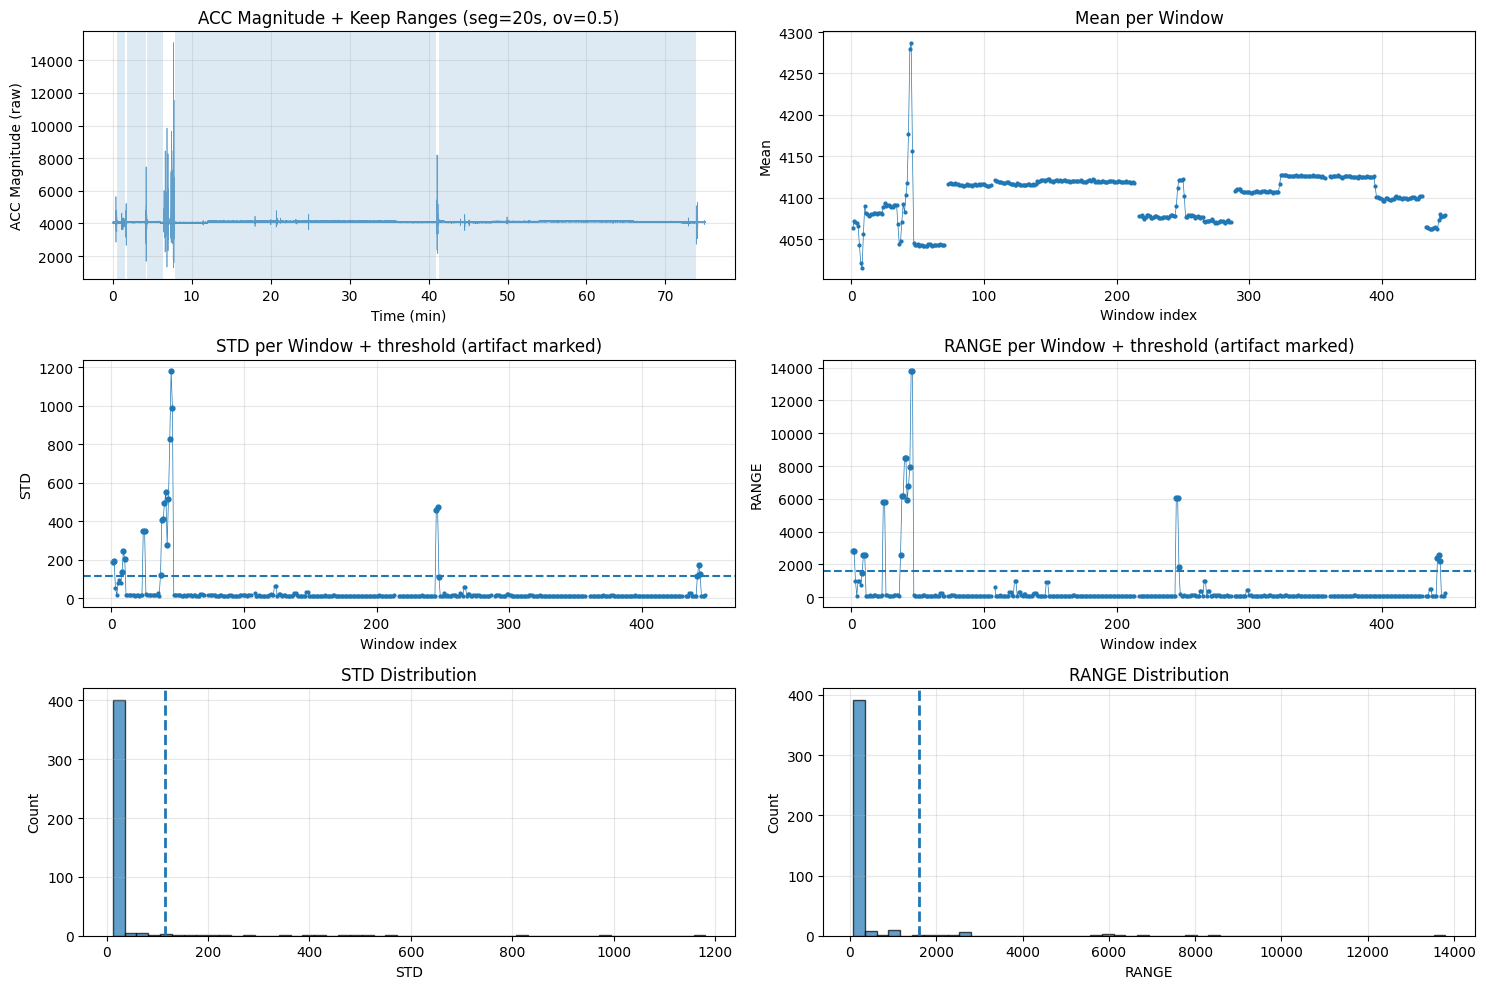


SAVED FILES
✓ Window stats (all)      : /content/drive/MyDrive/Colab Notebooks/RealPPG/acc_window_stats.csv
✓ Keep windows            : /content/drive/MyDrive/Colab Notebooks/RealPPG/keep_windows.csv
✓ Keep ranges (merged)    : /content/drive/MyDrive/Colab Notebooks/RealPPG/keep_ranges.csv
✓ Artifact windows        : /content/drive/MyDrive/Colab Notebooks/RealPPG/artifact_windows.csv
✓ Figure                 : /content/drive/MyDrive/Colab Notebooks/RealPPG/acc_analysis.png
------------------------------------------------------------
해석 요약:
- keep_ranges는 '아티팩트가 적은(상대적으로 정적인) 구간'이며, 동일 시간대 PPG/HR에서 모션 아티팩트 제거 마스크로 쓰기 적합합니다.
- 임계는 Q_STD/Q_RANGE로 조절합니다. (더 많이 제거하려면 0.90, 덜 제거하려면 0.97~0.99 등)


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 설정
# =========================
FILE_A   = "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001.csv"
FS_A     = 25.0

# 파일 시작을 START_DT로 가정해 절대시간 생성
START_DT = "2025-09-11 22:47:00"
END_DT   = "2025-09-12 07:08:00"

# 실제 분석(After-shift) 구간
T0 = "2025-09-11 22:47:00"
T1 = "2025-09-12 00:02:03.960000"

# 윈도우
SEG_SEC  = 20
OVERLAP  = 0.5

# =========================
# QC (tighter) 파라미터
# =========================
MIN_VALID_RATIO = 0.98        # NaN 허용치 (0.95 -> 0.98)
MIN_SNR_DB      = 3.5         # SQI(SNR) 최소
MAX_IBI_CV      = 0.20        # IBI CV 상한 (리듬 불안정 제거)
MIN_PEAK_FRAC   = 0.60        # 기대 피크 수 대비 최소 비율
MIN_SIG_STD     = 1e-6        # flatline 방지

# =========================
# Artifact 제거(QC): ACC 기반 (PSD 없음)
# =========================

# 분위수 기반 임계(단위 불명확해도 동작)
Q_STD   = 0.95   # std 상위 5% 제거
Q_RANGE = 0.95   # range(max-min) 상위 5% 제거
REMOVE_MODE = "OR"  # "OR" 권장 ("AND"는 덜 공격적)

# 너무 짧게 남는 keep 구간은 버림(연속구간 병합 후 적용)
MIN_KEEP_RANGE_SEC = 60  # 0이면 비활성화

# =========================
# 저장 경로
# =========================
OUT_DIR = "/content/drive/MyDrive/Colab Notebooks/RealPPG/"
OUT_STATS_CSV    = OUT_DIR + "acc_window_stats.csv"
OUT_KEEP_WIN_CSV = OUT_DIR + "keep_windows.csv"
OUT_KEEP_RNG_CSV = OUT_DIR + "keep_ranges.csv"
OUT_ART_WIN_CSV  = OUT_DIR + "artifact_windows.csv"
OUT_PNG          = OUT_DIR + "acc_analysis.png"

# =========================
# 유틸 함수
# =========================
def merge_ranges(ranges):
    """ranges: list of (start_dt, end_dt)"""
    if not ranges:
        return []
    ranges = sorted(ranges, key=lambda x: x[0])
    merged = [[ranges[0][0], ranges[0][1]]]
    for s, e in ranges[1:]:
        if s <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(a, b) for a, b in merged]

def filter_min_duration(ranges, min_sec):
    if min_sec <= 0:
        return ranges
    out = []
    for s, e in ranges:
        if (e - s).total_seconds() >= min_sec:
            out.append((s, e))
    return out

def fmt_hms(seconds):
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds - (h*3600 + m*60)
    return f"{h:02d}:{m:02d}:{s:05.2f}"

def ranges_total_sec(ranges):
    return float(sum((e - s).total_seconds() for s, e in ranges))

def describe_series(x: pd.Series, name: str):
    q = x.quantile([0.5, 0.75, 0.9, 0.95, 0.99])
    print(f"\n[{name}]")
    print(f"  mean ± std : {x.mean():.3f} ± {x.std():.3f}")
    print(f"  min / max  : {x.min():.3f} / {x.max():.3f}")
    print(f"  median     : {q.loc[0.5]:.3f}")
    print(f"  q75/q90    : {q.loc[0.75]:.3f} / {q.loc[0.9]:.3f}")
    print(f"  q95/q99    : {q.loc[0.95]:.3f} / {q.loc[0.99]:.3f}")

# =========================
# 1) 데이터 로드 + 절대시간 생성 + 구간 컷
# =========================
df0 = pd.read_csv(FILE_A)

dt_all = pd.to_datetime(START_DT) + pd.to_timedelta(np.arange(len(df0)) / FS_A, unit="s")
dt_all = pd.Series(dt_all)

# START_DT~END_DT 컷
s_dt = pd.to_datetime(START_DT)
e_dt = pd.to_datetime(END_DT)
mask = (dt_all >= s_dt) & (dt_all <= e_dt)
df = df0.loc[mask].reset_index(drop=True)
dt = dt_all.loc[mask].reset_index(drop=True)

# T0~T1 컷
t0 = pd.to_datetime(T0)
t1 = pd.to_datetime(T1)
mask2 = (dt >= t0) & (dt <= t1)
df = df.loc[mask2].reset_index(drop=True)
dt = dt.loc[mask2].reset_index(drop=True)

# ACC magnitude
acc_cols = ["acc_x", "acc_y", "acc_z"]
a = df[acc_cols].values.astype(float)
acc_mag = np.sqrt(np.sum(a**2, axis=1))

total_samples = len(acc_mag)
total_sec = total_samples / FS_A
print("============================================================")
print("ACC Artifact Removal (ACC-only QC) - RUN SUMMARY")
print("============================================================")
print(f"- File: {FILE_A}")
print(f"- FS: {FS_A} Hz")
print(f"- Absolute base: {START_DT} ~ {END_DT}")
print(f"- Analysis range: {T0} ~ {T1}")
print(f"- Total samples in analysis range: {total_samples} ({fmt_hms(total_sec)})")
print(f"- Window: {SEG_SEC}s, overlap={OVERLAP}")
print("------------------------------------------------------------")

if total_samples < int(FS_A * SEG_SEC * 1.2):
    print("⚠ 분석 구간이 너무 짧습니다. 윈도우 통계가 불안정할 수 있습니다.")

# =========================
# 2) 윈도우 생성
# =========================
step = int(SEG_SEC * (1 - OVERLAP))
analysis_total_sec = int((dt.iloc[-1] - dt.iloc[0]).total_seconds())
starts = range(0, max(0, analysis_total_sec - SEG_SEC + 1), step)

windows = [
    (dt.iloc[0] + pd.Timedelta(seconds=s), dt.iloc[0] + pd.Timedelta(seconds=s + SEG_SEC))
    for s in starts
]
print(f"- Candidate windows: {len(windows)}")

# =========================
# 3) 윈도우 통계
# =========================
need_n = SEG_SEC * FS_A * 0.8
stats = []

for i, (ws, we) in enumerate(windows):
    m = (dt >= ws) & (dt < we)
    x = acc_mag[m.values]
    if len(x) < need_n:
        continue

    mean_acc = float(np.mean(x))
    std_acc  = float(np.std(x))
    max_acc  = float(np.max(x))
    min_acc  = float(np.min(x))
    med_acc  = float(np.median(x))
    rng_acc  = float(max_acc - min_acc)
    spike_acc= float(max_acc - med_acc)

    stats.append({
        "window": i,
        "start": ws,
        "end": we,
        "mean": mean_acc,
        "std": std_acc,
        "max": max_acc,
        "min": min_acc,
        "median": med_acc,
        "range": rng_acc,
        "spike": spike_acc,
        "n": int(len(x)),
    })

df_stats = pd.DataFrame(stats)
print(f"- Computed windows (>=80% samples): {len(df_stats)}")

if len(df_stats) == 0:
    raise RuntimeError("윈도우 통계가 0개입니다. (구간/FS/윈도우 설정 확인 필요)")

# =========================
# 4) Artifact 판정 (분위수 임계)
# =========================
thr_std   = df_stats["std"].quantile(Q_STD)
thr_range = df_stats["range"].quantile(Q_RANGE)

if REMOVE_MODE.upper() == "AND":
    artifact = (df_stats["std"] > thr_std) & (df_stats["range"] > thr_range)
else:
    artifact = (df_stats["std"] > thr_std) | (df_stats["range"] > thr_range)

keep = ~artifact

df_stats["thr_std"]   = thr_std
df_stats["thr_range"] = thr_range
df_stats["artifact"]  = artifact
df_stats["keep"]      = keep

# =========================
# 5) keep 윈도우 -> keep 구간(연속 병합) -> 최소길이 필터
# =========================
keep_ranges = [(r["start"], r["end"]) for _, r in df_stats.loc[keep].iterrows()]
keep_ranges_merged = merge_ranges(keep_ranges)
keep_ranges_merged = filter_min_duration(keep_ranges_merged, MIN_KEEP_RANGE_SEC)

df_keep_ranges = pd.DataFrame(keep_ranges_merged, columns=["start", "end"])

# sample-level keep 마스크
keep_idx = np.zeros(len(dt), dtype=bool)
for s, e in keep_ranges_merged:
    keep_idx |= ((dt >= s) & (dt < e)).values

acc_keep = acc_mag[keep_idx]
dt_keep  = dt[keep_idx].reset_index(drop=True)

# =========================
# 6) 분석 결과 “즉시 출력” (저장만 하지 않도록)
# =========================
print("\n============================================================")
print("ANALYSIS RESULTS")
print("============================================================")

# 전체 ACC 요약
print("\n[ACC magnitude (analysis range) - raw]")
print(f"  mean ± std : {acc_mag.mean():.3f} ± {acc_mag.std():.3f}")
print(f"  min / max  : {acc_mag.min():.3f} / {acc_mag.max():.3f}")

# 윈도우 분포 요약
describe_series(df_stats["std"], "Window STD (movement)")
describe_series(df_stats["range"], "Window RANGE (max-min)")

print("\n[QC thresholds]")
print(f"  thr_std   = quantile({Q_STD:.2f}) = {thr_std:.3f}")
print(f"  thr_range = quantile({Q_RANGE:.2f}) = {thr_range:.3f}")
print(f"  REMOVE_MODE = {REMOVE_MODE}  (std>thr_std {REMOVE_MODE} range>thr_range)")

n_win = len(df_stats)
n_keep = int(keep.sum())
n_art  = int(artifact.sum())
print("\n[QC window counts]")
print(f"  keep windows    : {n_keep}/{n_win} ({(n_keep/n_win*100):.1f}%)")
print(f"  artifact windows: {n_art}/{n_win} ({(n_art/n_win*100):.1f}%)")

# 시간 커버리지(병합 구간 기준)
keep_sec = ranges_total_sec(keep_ranges_merged)
remove_sec = total_sec - keep_sec
print("\n[QC time coverage]")
print(f"  keep duration   : {fmt_hms(keep_sec)} ({(keep_sec/total_sec*100 if total_sec>0 else 0):.1f}%)")
print(f"  removed duration: {fmt_hms(remove_sec)} ({(remove_sec/total_sec*100 if total_sec>0 else 0):.1f}%)")
print(f"  merged keep ranges: {len(keep_ranges_merged)} (min_keep_sec={MIN_KEEP_RANGE_SEC})")

if len(keep_ranges_merged) > 0:
    # 최장 keep 구간
    durs = [(e - s).total_seconds() for s, e in keep_ranges_merged]
    k = int(np.argmax(durs))
    print("\n[Longest keep range]")
    print(f"  start: {keep_ranges_merged[k][0]}")
    print(f"  end  : {keep_ranges_merged[k][1]}")
    print(f"  dur  : {fmt_hms(durs[k])}")

# 가장 큰 아티팩트 후보(윈도우 상위 10개): std 기준/ range 기준 각각
df_art = df_stats.loc[artifact].copy()
df_keep = df_stats.loc[keep].copy()

print("\n[Top-10 artifact windows by STD] (큰 움직임 후보)")
if len(df_art) == 0:
    print("  (없음) 현재 설정에서는 아티팩트로 분류된 윈도우가 없습니다.")
else:
    top_std = df_art.sort_values("std", ascending=False).head(10)
    print(top_std[["window","start","end","std","range","spike","mean"]].to_string(index=False))

print("\n[Top-10 artifact windows by RANGE] (충격/스파이크 후보)")
if len(df_art) == 0:
    print("  (없음)")
else:
    top_rng = df_art.sort_values("range", ascending=False).head(10)
    print(top_rng[["window","start","end","std","range","spike","mean"]].to_string(index=False))

print("\n[Top-10 keep windows by lowest STD] (가장 정적인 구간 후보)")
top_keep = df_keep.sort_values("std", ascending=True).head(10)
print(top_keep[["window","start","end","std","range","spike","mean"]].to_string(index=False))

# =========================
# 7) 시각화 + 저장
# =========================
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

# (1) 전체 ACC + keep 구간 음영
ax = axes[0, 0]
t_min = (dt - dt.iloc[0]).dt.total_seconds().values / 60.0
ax.plot(t_min, acc_mag, linewidth=0.5, alpha=0.7)
ax.set_xlabel("Time (min)")
ax.set_ylabel("ACC Magnitude (raw)")
ax.set_title(f"ACC Magnitude + Keep Ranges (seg={SEG_SEC}s, ov={OVERLAP})")
ax.grid(True, alpha=0.3)

for s, e in keep_ranges_merged:
    s_min = (s - dt.iloc[0]).total_seconds() / 60.0
    e_min = (e - dt.iloc[0]).total_seconds() / 60.0
    ax.axvspan(s_min, e_min, alpha=0.15)

# (2) 윈도우 mean
ax = axes[0, 1]
ax.plot(df_stats["window"], df_stats["mean"], marker="o", markersize=2, linewidth=0.5)
ax.set_xlabel("Window index")
ax.set_ylabel("Mean")
ax.set_title("Mean per Window")
ax.grid(True, alpha=0.3)

# (3) 윈도우 std + threshold + artifact 표시
ax = axes[1, 0]
ax.plot(df_stats["window"], df_stats["std"], marker="o", markersize=2, linewidth=0.5)
ax.axhline(y=thr_std, linestyle="--", linewidth=1.5)
ax.scatter(df_stats.loc[artifact, "window"], df_stats.loc[artifact, "std"], s=12)
ax.set_xlabel("Window index")
ax.set_ylabel("STD")
ax.set_title("STD per Window + threshold (artifact marked)")
ax.grid(True, alpha=0.3)

# (4) 윈도우 range + threshold + artifact 표시
ax = axes[1, 1]
ax.plot(df_stats["window"], df_stats["range"], marker="o", markersize=2, linewidth=0.5)
ax.axhline(y=thr_range, linestyle="--", linewidth=1.5)
ax.scatter(df_stats.loc[artifact, "window"], df_stats.loc[artifact, "range"], s=12)
ax.set_xlabel("Window index")
ax.set_ylabel("RANGE")
ax.set_title("RANGE per Window + threshold (artifact marked)")
ax.grid(True, alpha=0.3)

# (5) std 히스토그램
ax = axes[2, 0]
ax.hist(df_stats["std"].dropna(), bins=50, alpha=0.7, edgecolor="black")
ax.axvline(x=thr_std, linestyle="--", linewidth=2)
ax.set_xlabel("STD")
ax.set_ylabel("Count")
ax.set_title("STD Distribution")
ax.grid(True, alpha=0.3)

# (6) range 히스토그램
ax = axes[2, 1]
ax.hist(df_stats["range"].dropna(), bins=50, alpha=0.7, edgecolor="black")
ax.axvline(x=thr_range, linestyle="--", linewidth=2)
ax.set_xlabel("RANGE")
ax.set_ylabel("Count")
ax.set_title("RANGE Distribution")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
plt.show()

# =========================
# 8) 저장 + 저장 사실/경로 출력
# =========================
df_stats.to_csv(OUT_STATS_CSV, index=False)
df_stats.loc[keep].to_csv(OUT_KEEP_WIN_CSV, index=False)
df_keep_ranges.to_csv(OUT_KEEP_RNG_CSV, index=False)
df_stats.loc[artifact].to_csv(OUT_ART_WIN_CSV, index=False)

print("\n============================================================")
print("SAVED FILES")
print("============================================================")
print(f"✓ Window stats (all)      : {OUT_STATS_CSV}")
print(f"✓ Keep windows            : {OUT_KEEP_WIN_CSV}")
print(f"✓ Keep ranges (merged)    : {OUT_KEEP_RNG_CSV}")
print(f"✓ Artifact windows        : {OUT_ART_WIN_CSV}")
print(f"✓ Figure                 : {OUT_PNG}")
print("------------------------------------------------------------")
print("해석 요약:")
print("- keep_ranges는 '아티팩트가 적은(상대적으로 정적인) 구간'이며, 동일 시간대 PPG/HR에서 모션 아티팩트 제거 마스크로 쓰기 적합합니다.")
print("- 임계는 Q_STD/Q_RANGE로 조절합니다. (더 많이 제거하려면 0.90, 덜 제거하려면 0.97~0.99 등)")
print("============================================================")


In [ ]:
“ACC로 움직임 아트팩트 구간을 먼저 제거한 뒤, 남은 구간에서 25Hz(A)와 200Hz(C)의 PPG 품질과 HR을 윈도우 단위로 비교

https://chatgpt.com/s/t_6954b5f271a0819183a1534889440a32

<ACC로 움직임 아트팩트 구간을 먼저 제거한 뒤, 남은 구간에서 25Hz(A)와 200Hz(C)의 PPG 품질과 HR을 윈도우 단위로 비교>


HR 상관(r), MAE, RMSE, Bias(C-A)
SQI는 A와 C 각각 분포 요약(mean/median/q10/q90)
시각화(Scatter, Bland-Altman, SQI histogram)


PPG QUALITY COMPARE (25Hz vs 200Hz) - SETUP
A(25Hz) file: /content/drive/MyDrive/Colab Notebooks/RealPPG/E0001.csv
  selected PPG col: ppg
C(200Hz) file: /content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw.csv
  load mode: header=None (fixed)
  selected PPG col: 1 (score=1.402e+01)
Analysis range: 2025-09-11 22:47:00 ~ 2025-09-12 00:02:03.960000
A samples: 112600  | C samples: 900793
------------------------------------------------------------


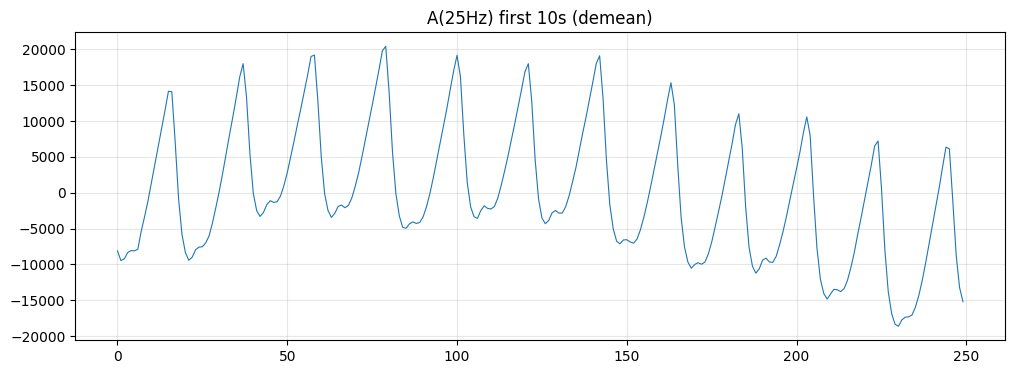

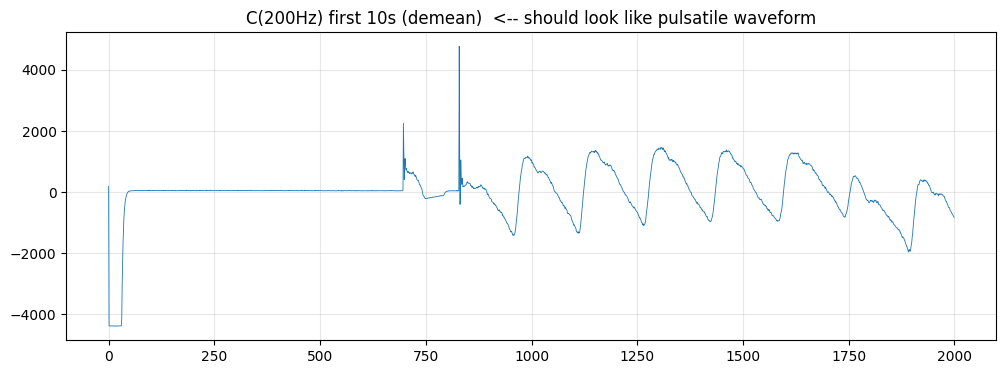

KEEP MASK APPLIED
A keep: 106500/112600 (94.6%)
C keep: 852000/900793 (94.6%)
------------------------------------------------------------
Computed windows (both A & C present): 420

RESULT SUMMARY
[HR agreement on BOTH-OK windows]
  n=359, r=0.381, MAE=5.607 bpm, RMSE=7.023 bpm, Bias(C-A)=5.066 bpm

[SQI (SNR dB) distribution]
  A(25Hz):  n=420, mean=7.105, med=7.236, q10=5.870, q90=8.586
  C(200Hz): n=420, mean=6.891, med=7.802, q10=3.314, q90=8.482

[Pass rates]
  okA: 96.4%  | okC: 89.0%  | both_ok: 85.5%



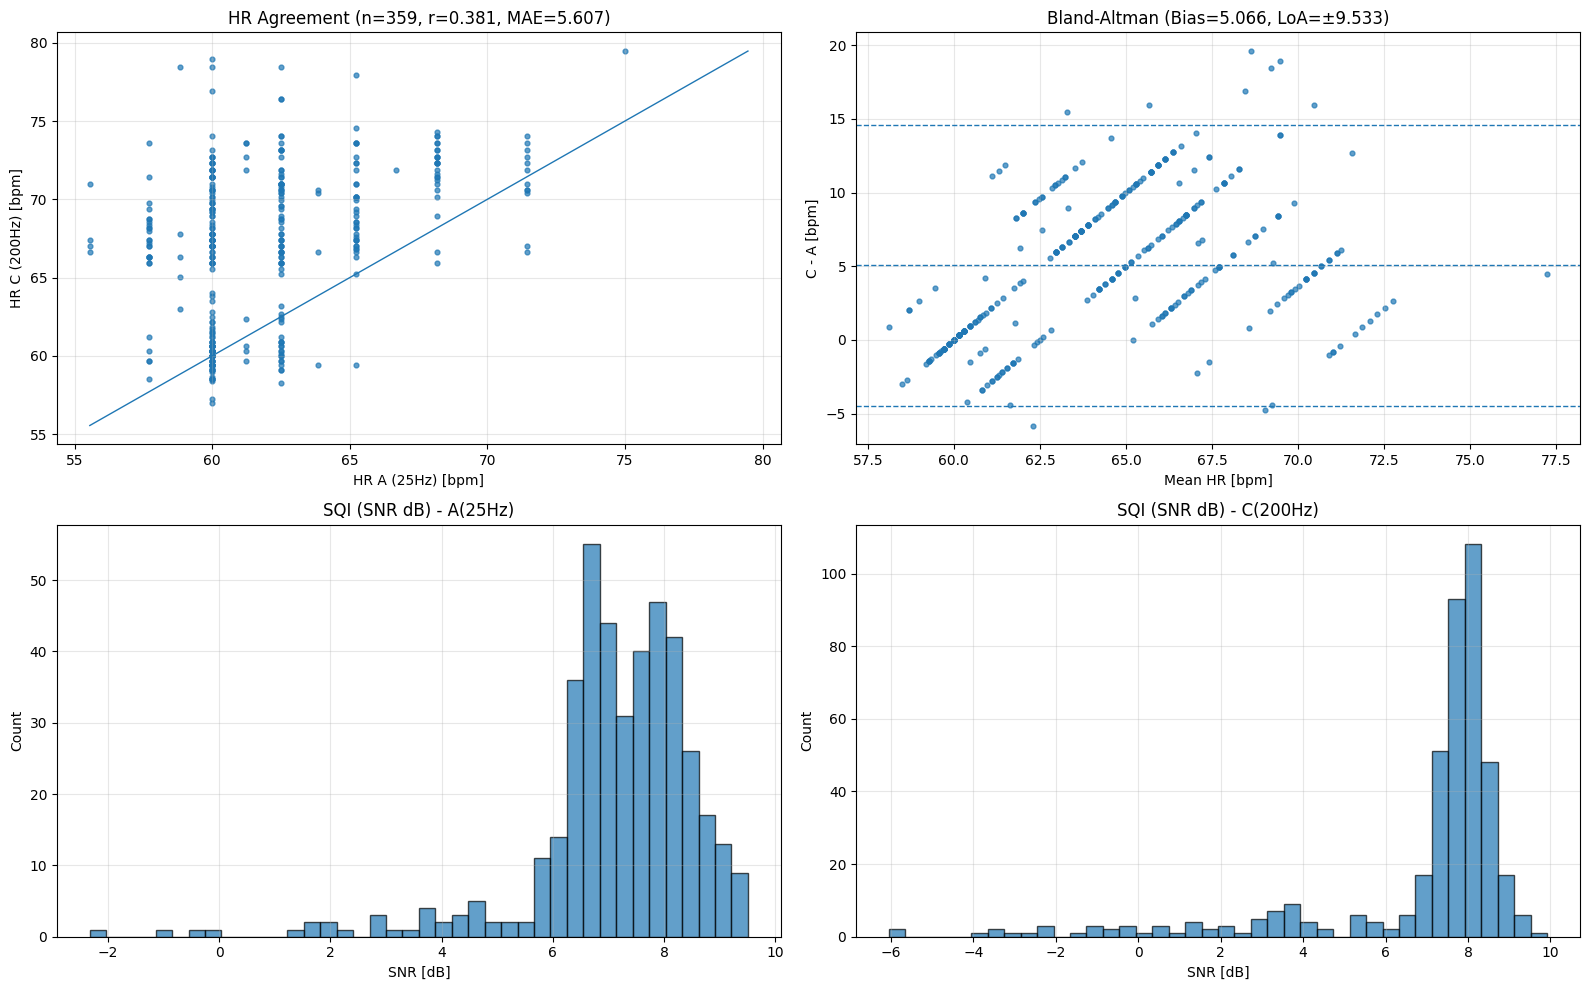

SAVED
  window-level results CSV: /content/drive/MyDrive/Colab Notebooks/RealPPG/ppg_quality_windows.csv
  figure PNG: /content/drive/MyDrive/Colab Notebooks/RealPPG/ppg_quality_compare.png

CSV 컬럼 설명(핵심):
  hrA/hrC: 윈도우 내 피크 기반 HR(bpm)
  snrA_db/snrC_db: 윈도우 내 스펙트럼 SNR 기반 SQI(dB)
  okA/okC: HR이 범위 내이며 피크 충분하면 True
  start/end: 윈도우 절대시간
  ppgC_col/ppgC_load_mode: 200Hz에서 선택된 컬럼 및 로딩모드


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, welch

# ============================================================
# 0) 사용자 설정
# ============================================================
FILE_A_25 = "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001.csv"
FS_A = 25.0

FILE_C_200 = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw.csv"
FS_C = 200.0

ABS_START_A = "2025-09-11 22:47:00"
ABS_START_C = "2025-09-11 22:47:00"

ANALYSIS_T0 = "2025-09-11 22:47:00"
ANALYSIS_T1 = "2025-09-12 00:02:03.960000"

KEEP_RANGES_CSV = "/content/drive/MyDrive/Colab Notebooks/RealPPG/keep_ranges.csv"

SEG_SEC = 20
OVERLAP = 0.5

MIN_BPM = 40
MAX_BPM = 180

BPF_LO = 0.5
BPF_HI = 4.0

SAVE_PNG = True
OUT_PNG = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppg_quality_compare.png"
OUT_CSV = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppg_quality_windows.csv"


# ============================================================
# 1) 유틸
# ============================================================
def build_dt_series(n, fs, abs_start_str):
    abs_start = pd.to_datetime(abs_start_str)
    return pd.Series(abs_start + pd.to_timedelta(np.arange(n) / fs, unit="s"))

def cut_by_abs_range(df, dt, t0, t1):
    t0 = pd.to_datetime(t0); t1 = pd.to_datetime(t1)
    m = (dt >= t0) & (dt <= t1)
    return df.loc[m].reset_index(drop=True), dt.loc[m].reset_index(drop=True)

def load_keep_ranges(path_csv):
    d = pd.read_csv(path_csv)
    d["start"] = pd.to_datetime(d["start"])
    d["end"]   = pd.to_datetime(d["end"])
    return list(zip(d["start"], d["end"]))

def apply_ranges(dt, ranges):
    keep = np.zeros(len(dt), dtype=bool)
    for s, e in ranges:
        keep |= ((dt >= s) & (dt < e)).values
    return keep

def robust_ppg_column(df):
    candidates = ["ppg","PPG","ppg_raw","ppg_ir","ir","IR","green","GREEN","pleth","PLETH","value","Value","sensor","raw"]
    cols = list(df.columns)
    for c in candidates:
        if c in cols:
            return c
    num_cols = []
    for c in cols:
        x = pd.to_numeric(df[c], errors="coerce")
        if x.notna().sum() > 0 and np.nanstd(x.values) > 0:
            num_cols.append(c)
    if not num_cols:
        raise ValueError("PPG로 쓸 숫자형 컬럼을 못 찾았습니다.")
    best = max(num_cols, key=lambda c: np.nanstd(pd.to_numeric(df[c], errors="coerce").values))
    return best

def bandpass(x, fs, lo, hi, order=3):
    x = np.asarray(x, dtype=float)
    x = x - np.nanmean(x)
    nyq = 0.5 * fs
    lo_n = max(lo / nyq, 1e-4)
    hi_n = min(hi / nyq, 0.999)
    b, a = butter(order, [lo_n, hi_n], btype="band")
    if len(x) < (order * 6 + 1):
        return x
    return filtfilt(b, a, x)


def estimate_hr_and_sqi(ppg_seg, fs, min_bpm=40, max_bpm=180):

    # --- defaults (no external globals needed) ---
    MIN_VALID_RATIO = 0.98
    MIN_SNR_DB      = 3.5
    MAX_IBI_CV      = 0.20
    MIN_PEAK_FRAC   = 0.60
    MIN_SIG_STD     = 1e-6

    """
    반환:
      hr_bpm, snr_db, ok, valid_ratio, n_peaks, ibi_cv, prom_med
    """
    x = np.asarray(ppg_seg, dtype=float)
    valid_ratio = np.isfinite(x).mean()
    if valid_ratio < MIN_VALID_RATIO:
        return np.nan, np.nan, False, valid_ratio, 0, np.nan, np.nan

    # bandpass
    xf = bandpass(x, fs, BPF_LO, BPF_HI, order=3)
    if not np.isfinite(xf).all():
        return np.nan, np.nan, False, valid_ratio, 0, np.nan, np.nan

    sig_std = float(np.std(xf))
    if sig_std <= MIN_SIG_STD:
        return np.nan, np.nan, False, valid_ratio, 0, np.nan, np.nan

    # 피크 탐지
    min_dist = max(1, int(fs * (60.0 / max_bpm)))
    prom_thr = 0.3 * sig_std
    if not np.isfinite(prom_thr) or prom_thr <= 0:
        prom_thr = None

    peaks, props = find_peaks(xf, distance=min_dist, prominence=prom_thr)
    n_peaks = int(len(peaks))
    prom_med = np.nan
    if "prominences" in props and len(props["prominences"]) > 0:
        prom_med = float(np.median(props["prominences"]))

    # HR + IBI-CV
    hr_bpm = np.nan
    ibi_cv = np.nan
    if n_peaks >= 3:
        ibi = np.diff(peaks) / fs
        ibi = ibi[(ibi > 60.0/max_bpm) & (ibi < 60.0/min_bpm)]
        if len(ibi) >= 2:
            hr_bpm = 60.0 / np.median(ibi)
            mu = float(np.mean(ibi))
            sd = float(np.std(ibi))
            ibi_cv = (sd / mu) if mu > 1e-9 else np.inf

    # SNR(SQI)
    snr_db = np.nan
    try:
        nperseg = min(len(xf), int(fs * 10))
        if nperseg >= int(fs * 3):
            f, pxx = welch(xf, fs=fs, nperseg=nperseg, noverlap=nperseg//2, detrend="constant")
            band = (f >= BPF_LO) & (f <= BPF_HI)
            if band.sum() >= 5:
                fb = f[band]; pb = pxx[band]
                k = int(np.argmax(pb))
                f0 = fb[k]
                sig = (f >= (f0 - 0.15)) & (f <= (f0 + 0.15)) & band
                noi = band & (~sig)
                ps = np.sum(pxx[sig]) + 1e-12
                pn = np.sum(pxx[noi]) + 1e-12
                snr_db = 10.0 * np.log10(ps / pn)
    except Exception:
        snr_db = np.nan

    # ---- tighter OK 조건 ----
    # 기대 피크 수(최소 BPM 기준) 대비 MIN_PEAK_FRAC 이상
    expected_peaks_min = SEG_SEC * (min_bpm / 60.0)
    min_peaks_required = int(np.ceil(expected_peaks_min * MIN_PEAK_FRAC))
    min_peaks_required = max(3, min_peaks_required)

    ok = True
    ok &= np.isfinite(hr_bpm) and (min_bpm <= hr_bpm <= max_bpm)
    ok &= (n_peaks >= min_peaks_required)
    ok &= np.isfinite(snr_db) and (snr_db >= MIN_SNR_DB)
    ok &= np.isfinite(ibi_cv) and (ibi_cv <= MAX_IBI_CV)

    return float(hr_bpm), float(snr_db), bool(ok), float(valid_ratio), n_peaks, float(ibi_cv), float(prom_med)



def window_iter(dt0, dt1, seg_sec, overlap):
    step = int(seg_sec * (1 - overlap))
    total_sec = int((dt1 - dt0).total_seconds())
    for s in range(0, max(0, total_sec - seg_sec + 1), step):
        ws = dt0 + pd.Timedelta(seconds=s)
        we = ws + pd.Timedelta(seconds=seg_sec)
        yield ws, we

def fmt(x):
    return "nan" if not np.isfinite(x) else f"{x:.3f}"


# ============================================================
# 2) 200Hz(C) 자동 PPG 컬럼 선택 (램프/시간열 배제 + HRband score)
# ============================================================
def _is_ramp_like(x):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    if m.mean() < 0.95:
        return True
    x = x[m]
    if len(x) < 200:
        return True
    idx = np.arange(len(x), dtype=float)
    r = np.corrcoef(x, idx)[0, 1]
    return np.isfinite(r) and (abs(r) > 0.995)

def _hrband_score(x, fs, lo=0.5, hi=4.0):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    if m.mean() < 0.95:
        return -np.inf
    x = x[m]
    if len(x) < int(fs * 6):
        return -np.inf

    xf = bandpass(x, fs, lo, hi, order=3)
    nperseg = min(len(xf), int(fs * 10))
    if nperseg < int(fs * 3):
        return -np.inf

    f, pxx = welch(xf, fs=fs, nperseg=nperseg, noverlap=nperseg//2, detrend="constant")
    band = (f >= lo) & (f <= hi)
    if band.sum() < 5:
        return -np.inf

    p_band = np.sum(pxx[band]) + 1e-12
    p_all  = np.sum(pxx) + 1e-12
    ratio = p_band / p_all

    peakiness = (np.max(pxx[band]) / (np.mean(pxx[band]) + 1e-12))
    return float(ratio * peakiness)

def load_ppg_C_auto(file_c_200, fs_c, abs_start_c):
    df0 = pd.read_csv(file_c_200)
    cols0 = list(df0.columns.astype(str))
    has_numeric_header = any(c.strip().replace(".", "", 1).isdigit() for c in cols0)

    if has_numeric_header:
        df = pd.read_csv(file_c_200, header=None)
        header_mode = "header=None (fixed)"
    else:
        df = df0
        header_mode = "normal header"

    # 숫자 후보 컬럼
    cand = []
    for c in df.columns:
        x = pd.to_numeric(df[c], errors="coerce").values
        if np.isfinite(x).mean() < 0.5:
            continue
        if np.nanstd(x) <= 0:
            continue
        cand.append(c)
    if not cand:
        raise ValueError("C(200Hz)에서 유효한 숫자 컬럼 후보를 못 찾았습니다.")

    # 램프 배제 + HRband score 최대 선택
    best_c, best_s = None, -np.inf
    for c in cand:
        x = pd.to_numeric(df[c], errors="coerce").values.astype(float)
        if _is_ramp_like(x):
            continue
        s = _hrband_score(x, fs_c, BPF_LO, BPF_HI)
        if s > best_s:
            best_s = s
            best_c = c

    # 전부 램프로 판정되면 score만으로 선택(최후수단)
    if best_c is None:
        for c in cand:
            x = pd.to_numeric(df[c], errors="coerce").values.astype(float)
            s = _hrband_score(x, fs_c, BPF_LO, BPF_HI)
            if s > best_s:
                best_s, best_c = s, c

    dt = build_dt_series(len(df), fs_c, abs_start_c)
    return df, dt, best_c, header_mode, best_s


# ============================================================
# 3) A/C 로드 + 절대시간 + 분석구간 컷
# ============================================================
# --- A ---
dfA_full = pd.read_csv(FILE_A_25)
dtA_full = build_dt_series(len(dfA_full), FS_A, ABS_START_A)
dfA, dtA = cut_by_abs_range(dfA_full, dtA_full, ANALYSIS_T0, ANALYSIS_T1)

colA = robust_ppg_column(dfA)
ppgA = pd.to_numeric(dfA[colA], errors="coerce").values.astype(float)

# --- C (수정된 로직) ---
dfC_full, dtC_full, colC, header_mode_C, scoreC = load_ppg_C_auto(FILE_C_200, FS_C, ABS_START_C)

# ★ 여기서 df/dt 같이 자르고
dfC, dtC = cut_by_abs_range(dfC_full, dtC_full, ANALYSIS_T0, ANALYSIS_T1)

# ★ ppgC는 "잘린 dfC"에서 다시 뽑는다 (길이 불일치 방지)
ppgC = pd.to_numeric(dfC[colC], errors="coerce").values.astype(float)

print("============================================================")
print("PPG QUALITY COMPARE (25Hz vs 200Hz) - SETUP")
print("============================================================")
print(f"A(25Hz) file: {FILE_A_25}")
print(f"  selected PPG col: {colA}")
print(f"C(200Hz) file: {FILE_C_200}")
print(f"  load mode: {header_mode_C}")
print(f"  selected PPG col: {colC} (score={scoreC:.3e})")
print(f"Analysis range: {ANALYSIS_T0} ~ {ANALYSIS_T1}")
print(f"A samples: {len(ppgA)}  | C samples: {len(ppgC)}")
print("------------------------------------------------------------")

# sanity plot
sec = 10
nA = int(FS_A * sec)
nC = int(FS_C * sec)

plt.figure(figsize=(12,4))
plt.plot(ppgA[:nA] - np.nanmean(ppgA[:nA]), linewidth=0.8)
plt.title("A(25Hz) first 10s (demean)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(ppgC[:nC] - np.nanmean(ppgC[:nC]), linewidth=0.6)
plt.title("C(200Hz) first 10s (demean)  <-- should look like pulsatile waveform")
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# 4) keep_ranges 적용
# ============================================================
keep_ranges = load_keep_ranges(KEEP_RANGES_CSV)
keepA = apply_ranges(dtA, keep_ranges)
keepC = apply_ranges(dtC, keep_ranges)

ppgA_k = ppgA[keepA]
dtA_k  = dtA[keepA].reset_index(drop=True)

ppgC_k = ppgC[keepC]
dtC_k  = dtC[keepC].reset_index(drop=True)

print("KEEP MASK APPLIED")
print(f"A keep: {keepA.sum()}/{len(keepA)} ({keepA.mean()*100:.1f}%)")
print(f"C keep: {keepC.sum()}/{len(keepC)} ({keepC.mean()*100:.1f}%)")
print("------------------------------------------------------------")

# ============================================================
# 5) 윈도우별 품질평가 (HR + SQI)
# ============================================================
dt0 = max(dtA_k.iloc[0], dtC_k.iloc[0])
dt1 = min(dtA_k.iloc[-1], dtC_k.iloc[-1])

rows = []
needA = int(FS_A * SEG_SEC * 0.8)
needC = int(FS_C * SEG_SEC * 0.8)

for wi, (ws, we) in enumerate(window_iter(dt0, dt1, SEG_SEC, OVERLAP)):
    mA = (dtA_k >= ws) & (dtA_k < we)
    mC = (dtC_k >= ws) & (dtC_k < we)

    xA = ppgA_k[mA.values]
    xC = ppgC_k[mC.values]

    if len(xA) < needA or len(xC) < needC:
        continue

    hrA, snrA, okA, vrA, nPkA, cvA, promA = estimate_hr_and_sqi(xA, FS_A, MIN_BPM, MAX_BPM)
    hrC, snrC, okC, vrC, nPkC, cvC, promC = estimate_hr_and_sqi(xC, FS_C, MIN_BPM, MAX_BPM)

    rows.append({
        "win": wi,
        "start": ws,
        "end": we,
        "nA": len(xA),
        "nC": len(xC),
        "hrA": hrA,
        "hrC": hrC,
        "snrA_db": snrA,
        "snrC_db": snrC,
        "okA": okA,
        "okC": okC,
        "validA": vrA,
        "validC": vrC,
        "ppgC_col": str(colC),
        "ppgC_load_mode": header_mode_C,
        "nPeaksA": nPkA,
        "nPeaksC": nPkC,
        "ibiCvA": cvA,
        "ibiCvC": cvC,
        "promMedA": promA,
        "promMedC": promC
    })

dfW = pd.DataFrame(rows)
print(f"Computed windows (both A & C present): {len(dfW)}")

# ============================================================
# 6) 비교 지표 계산
# ============================================================
both_ok = dfW["okA"] & dfW["okC"] & np.isfinite(dfW["hrA"]) & np.isfinite(dfW["hrC"])
dfOK = dfW.loc[both_ok].copy()

def compare_stats(y, x):
    if len(y) < 3:
        return {"n": len(y), "r": np.nan, "mae": np.nan, "rmse": np.nan, "bias": np.nan}
    r = np.corrcoef(x, y)[0, 1]
    diff = (y - x)
    mae = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))
    bias = np.mean(diff)
    return {"n": len(y), "r": r, "mae": mae, "rmse": rmse, "bias": bias}

hr_cmp = compare_stats(dfOK["hrC"].values, dfOK["hrA"].values)

def sqi_summary(s):
    s = s[np.isfinite(s)]
    if len(s) == 0:
        return {"n": 0, "mean": np.nan, "med": np.nan, "q10": np.nan, "q90": np.nan}
    return {
        "n": len(s),
        "mean": float(np.mean(s)),
        "med": float(np.median(s)),
        "q10": float(np.quantile(s, 0.10)),
        "q90": float(np.quantile(s, 0.90)),
    }

sqiA = sqi_summary(dfW["snrA_db"].values)
sqiC = sqi_summary(dfW["snrC_db"].values)

print("\n============================================================")
print("RESULT SUMMARY")
print("============================================================")
print("[HR agreement on BOTH-OK windows]")
print(f"  n={hr_cmp['n']}, r={fmt(hr_cmp['r'])}, MAE={fmt(hr_cmp['mae'])} bpm, RMSE={fmt(hr_cmp['rmse'])} bpm, Bias(C-A)={fmt(hr_cmp['bias'])} bpm")
print("\n[SQI (SNR dB) distribution]")
print(f"  A(25Hz):  n={sqiA['n']}, mean={fmt(sqiA['mean'])}, med={fmt(sqiA['med'])}, q10={fmt(sqiA['q10'])}, q90={fmt(sqiA['q90'])}")
print(f"  C(200Hz): n={sqiC['n']}, mean={fmt(sqiC['mean'])}, med={fmt(sqiC['med'])}, q10={fmt(sqiC['q10'])}, q90={fmt(sqiC['q90'])}")
print("\n[Pass rates]")
print(f"  okA: {dfW['okA'].mean()*100:.1f}%  | okC: {dfW['okC'].mean()*100:.1f}%  | both_ok: {both_ok.mean()*100:.1f}%")
print("============================================================\n")

# ============================================================
# 7) 시각화
# ============================================================
fig = plt.figure(figsize=(16, 10))

ax1 = plt.subplot(2, 2, 1)
ax1.scatter(dfOK["hrA"], dfOK["hrC"], s=12, alpha=0.7)
mn = np.nanmin(np.r_[dfOK["hrA"].values, dfOK["hrC"].values]) if len(dfOK) else MIN_BPM
mx = np.nanmax(np.r_[dfOK["hrA"].values, dfOK["hrC"].values]) if len(dfOK) else MAX_BPM
ax1.plot([mn, mx], [mn, mx], linewidth=1)
ax1.set_xlabel("HR A (25Hz) [bpm]")
ax1.set_ylabel("HR C (200Hz) [bpm]")
ax1.set_title(f"HR Agreement (n={hr_cmp['n']}, r={fmt(hr_cmp['r'])}, MAE={fmt(hr_cmp['mae'])})")
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(2, 2, 2)
if len(dfOK) >= 3:
    mean_hr = (dfOK["hrA"].values + dfOK["hrC"].values) / 2
    diff_hr = (dfOK["hrC"].values - dfOK["hrA"].values)
    mu = np.mean(diff_hr)
    sd = np.std(diff_hr)
    ax2.scatter(mean_hr, diff_hr, s=12, alpha=0.7)
    ax2.axhline(mu, linestyle="--", linewidth=1)
    ax2.axhline(mu + 1.96*sd, linestyle="--", linewidth=1)
    ax2.axhline(mu - 1.96*sd, linestyle="--", linewidth=1)
    ax2.set_title(f"Bland-Altman (Bias={fmt(mu)}, LoA=±{fmt(1.96*sd)})")
else:
    ax2.text(0.1, 0.5, "Not enough BOTH-OK windows", transform=ax2.transAxes)
ax2.set_xlabel("Mean HR [bpm]")
ax2.set_ylabel("C - A [bpm]")
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(2, 2, 3)
ax3.hist(dfW["snrA_db"].dropna(), bins=40, alpha=0.7, edgecolor="black")
ax3.set_title("SQI (SNR dB) - A(25Hz)")
ax3.set_xlabel("SNR [dB]")
ax3.set_ylabel("Count")
ax3.grid(True, alpha=0.3)

ax4 = plt.subplot(2, 2, 4)
ax4.hist(dfW["snrC_db"].dropna(), bins=40, alpha=0.7, edgecolor="black")
ax4.set_title("SQI (SNR dB) - C(200Hz)")
ax4.set_xlabel("SNR [dB]")
ax4.set_ylabel("Count")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# 8) 저장
# ============================================================
dfW.to_csv(OUT_CSV, index=False)
print("SAVED")
print(f"  window-level results CSV: {OUT_CSV}")
if SAVE_PNG:
    print(f"  figure PNG: {OUT_PNG}")
print("\nCSV 컬럼 설명(핵심):")
print("  hrA/hrC: 윈도우 내 피크 기반 HR(bpm)")
print("  snrA_db/snrC_db: 윈도우 내 스펙트럼 SNR 기반 SQI(dB)")
print("  okA/okC: HR이 범위 내이며 피크 충분하면 True")
print("  start/end: 윈도우 절대시간")
print("  ppgC_col/ppgC_load_mode: 200Hz에서 선택된 컬럼 및 로딩모드")


아래 코드는 지금 저장된 ppg_quality_windows.csv만 가지고

현재 HR 비교 성능(원본 C vs A)

Bias 보정(C - bias) 후 성능

(옵션) 선형 보정(C를 A에 맞춤: slope/intercept) 후 성능을 즉시 계산/출력 + 그림(스캐터, Bland-Altman)


[RAW (C vs A)]
  n=359, r=0.381, MAE=5.607 bpm, RMSE=7.023 bpm
  Bias(C-A)=5.066 bpm, LoA=±9.546 bpm

[BIAS-CORRECTED (C-bias vs A)]
  n=359, r=0.381, MAE=4.136 bpm, RMSE=4.864 bpm
  Bias(C-A)=-0.000 bpm, LoA=±9.546 bpm

[LINEAR FIT] C ≈ a*A + b  (a=0.5766, b=31.2921)

[LINEAR-CORRECTED ((C-b)/a vs A)]
  n=359, r=0.381, MAE=6.758 bpm, RMSE=8.074 bpm
  Bias(C-A)=-0.000 bpm, LoA=±15.847 bpm


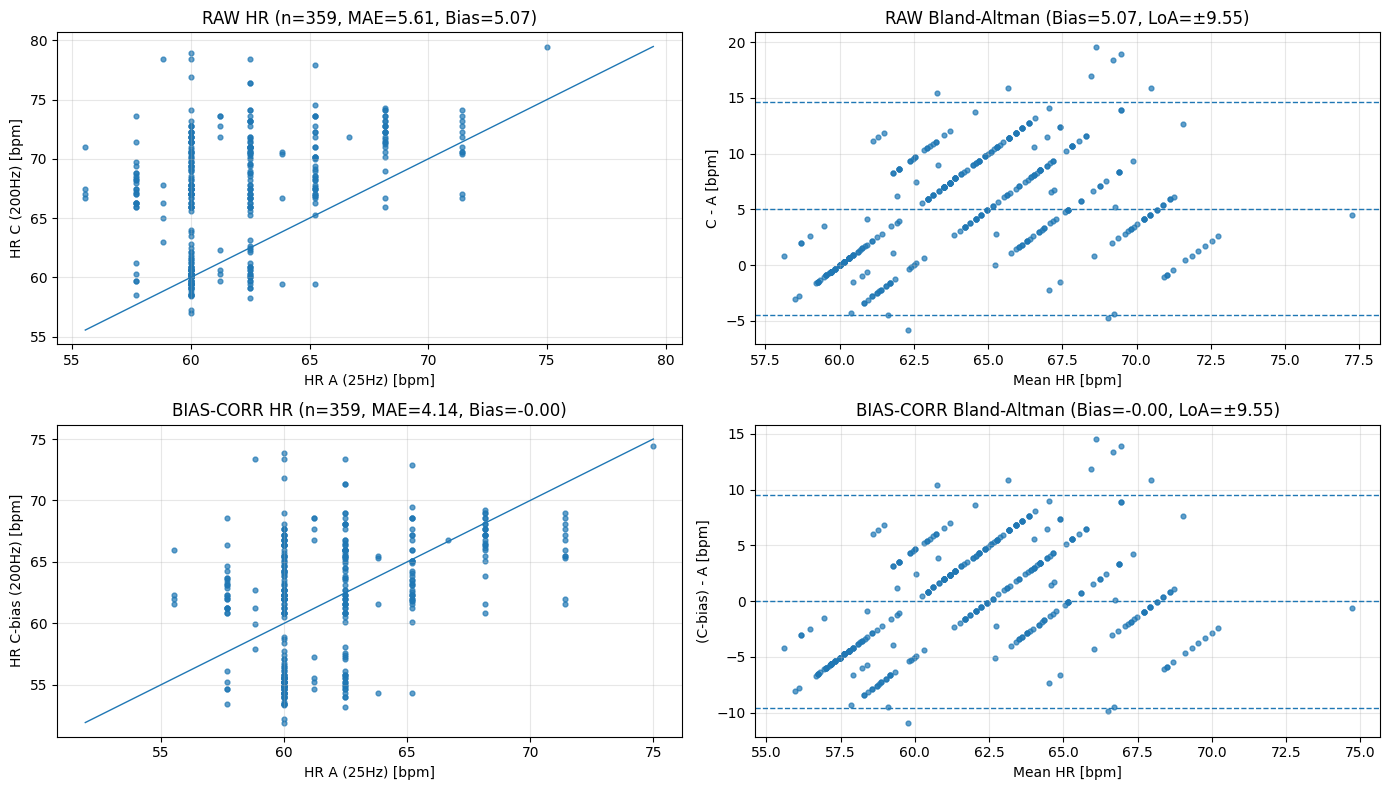


✓ Saved figure: /content/drive/MyDrive/Colab Notebooks/RealPPG/hr_compare_bias_corrected.png


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppg_quality_windows.csv"
OUT_PNG = "/content/drive/MyDrive/Colab Notebooks/RealPPG/hr_compare_bias_corrected.png"

df = pd.read_csv(CSV)

# --- 필수 컬럼 체크 ---
need_cols = ["hrA", "hrC", "okA", "okC"]
miss = [c for c in need_cols if c not in df.columns]
if miss:
    raise ValueError(f"CSV에 컬럼이 없습니다: {miss}")

# --- BOTH-OK 윈도우만 사용 ---
m = (df["okA"].astype(bool) & df["okC"].astype(bool) &
     np.isfinite(df["hrA"].values) & np.isfinite(df["hrC"].values))
d = df.loc[m].copy()

A = d["hrA"].to_numpy(float)
C = d["hrC"].to_numpy(float)

def metrics(x, y):
    # x: A(25), y: C(200)  / diff = y-x = (C-A)
    n = len(x)
    diff = y - x
    r = np.corrcoef(x, y)[0,1] if n >= 3 else np.nan
    mae = float(np.mean(np.abs(diff))) if n else np.nan
    rmse = float(np.sqrt(np.mean(diff**2))) if n else np.nan
    bias = float(np.mean(diff)) if n else np.nan
    sd = float(np.std(diff, ddof=1)) if n >= 2 else np.nan
    loa = float(1.96 * sd) if np.isfinite(sd) else np.nan
    return {"n": n, "r": r, "mae": mae, "rmse": rmse, "bias": bias, "loa": loa}

def print_metrics(tag, M):
    def f(v): return "nan" if not np.isfinite(v) else f"{v:.3f}"
    print(f"\n[{tag}]")
    print(f"  n={M['n']}, r={f(M['r'])}, MAE={f(M['mae'])} bpm, RMSE={f(M['rmse'])} bpm")
    print(f"  Bias(C-A)={f(M['bias'])} bpm, LoA=±{f(M['loa'])} bpm")

# (0) 원본
M0 = metrics(A, C)
print_metrics("RAW (C vs A)", M0)

# (1) Bias 보정: C' = C - mean(C-A)
bias = M0["bias"]
C_biascorr = C - bias
M1 = metrics(A, C_biascorr)
print_metrics("BIAS-CORRECTED (C-bias vs A)", M1)

# (2) 옵션: 선형 보정(스케일+오프셋): C' = (C - b)/a  또는 A' = a*A + b
# 여기서는 "C를 A에 맞추는 형태"로 C_lin = (C - b)/a 를 사용
if len(A) >= 5:
    a, b = np.polyfit(A, C, 1)  # C ≈ a*A + b
    C_lincorr = (C - b) / a if np.isfinite(a) and abs(a) > 1e-9 else C.copy()
    M2 = metrics(A, C_lincorr)
    print(f"\n[LINEAR FIT] C ≈ a*A + b  (a={a:.4f}, b={b:.4f})")
    print_metrics("LINEAR-CORRECTED ((C-b)/a vs A)", M2)
else:
    C_lincorr = None
    M2 = None

# --- 그림: RAW vs BIAS-CORR (스캐터 + Bland-Altman) ---
fig = plt.figure(figsize=(14, 8))

# Scatter RAW
ax1 = plt.subplot(2,2,1)
ax1.scatter(A, C, s=12, alpha=0.7)
mn = min(np.min(A), np.min(C))
mx = max(np.max(A), np.max(C))
ax1.plot([mn, mx], [mn, mx], linewidth=1)
ax1.set_title(f"RAW HR (n={M0['n']}, MAE={M0['mae']:.2f}, Bias={M0['bias']:.2f})")
ax1.set_xlabel("HR A (25Hz) [bpm]")
ax1.set_ylabel("HR C (200Hz) [bpm]")
ax1.grid(True, alpha=0.3)

# Bland-Altman RAW
ax2 = plt.subplot(2,2,2)
mean_hr = (A + C)/2
diff_hr = (C - A)
mu = np.mean(diff_hr); sd = np.std(diff_hr, ddof=1)
ax2.scatter(mean_hr, diff_hr, s=12, alpha=0.7)
ax2.axhline(mu, linestyle="--", linewidth=1)
ax2.axhline(mu + 1.96*sd, linestyle="--", linewidth=1)
ax2.axhline(mu - 1.96*sd, linestyle="--", linewidth=1)
ax2.set_title(f"RAW Bland-Altman (Bias={mu:.2f}, LoA=±{1.96*sd:.2f})")
ax2.set_xlabel("Mean HR [bpm]")
ax2.set_ylabel("C - A [bpm]")
ax2.grid(True, alpha=0.3)

# Scatter Bias-corrected
ax3 = plt.subplot(2,2,3)
ax3.scatter(A, C_biascorr, s=12, alpha=0.7)
mn = min(np.min(A), np.min(C_biascorr))
mx = max(np.max(A), np.max(C_biascorr))
ax3.plot([mn, mx], [mn, mx], linewidth=1)
ax3.set_title(f"BIAS-CORR HR (n={M1['n']}, MAE={M1['mae']:.2f}, Bias={M1['bias']:.2f})")
ax3.set_xlabel("HR A (25Hz) [bpm]")
ax3.set_ylabel("HR C-bias (200Hz) [bpm]")
ax3.grid(True, alpha=0.3)

# Bland-Altman Bias-corrected
ax4 = plt.subplot(2,2,4)
mean_hr2 = (A + C_biascorr)/2
diff_hr2 = (C_biascorr - A)
mu2 = np.mean(diff_hr2); sd2 = np.std(diff_hr2, ddof=1)
ax4.scatter(mean_hr2, diff_hr2, s=12, alpha=0.7)
ax4.axhline(mu2, linestyle="--", linewidth=1)
ax4.axhline(mu2 + 1.96*sd2, linestyle="--", linewidth=1)
ax4.axhline(mu2 - 1.96*sd2, linestyle="--", linewidth=1)
ax4.set_title(f"BIAS-CORR Bland-Altman (Bias={mu2:.2f}, LoA=±{1.96*sd2:.2f})")
ax4.set_xlabel("Mean HR [bpm]")
ax4.set_ylabel("(C-bias) - A [bpm]")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✓ Saved figure: {OUT_PNG}")
